# The resource-consumer NP model with odeint

In [18]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [19]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [20]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

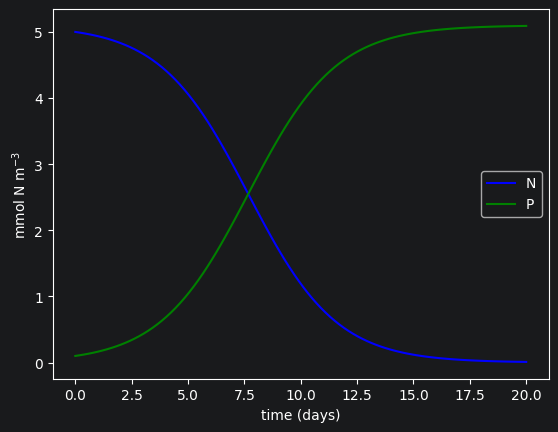

In [21]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()

# Exercise
1. What are the inputs and outputs in the function model? What kind of objects are they?

`state` is the current value of N and P stored in a numpy array, `t` is the scalar quantity representing the time $t$, and `k` is a constant that can be varied to change the rate of reaching equilibrium.

2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

We take the NPD equations to be
$$ \frac{dN}{dt} = -kNP + rD $$
$$ \frac{dP}{dt} = kNP - mP $$
$$ \frac{dD}{dt} = mP - rD $$

In [22]:
# function that returns the right hand side of the above equations
def model(state,t, k, r, m):
    N,P,D = state
    Ndot = -k * N * P + r*D
    Pdot =  k * N * P - m*P
    Ddot = m*P - r*D
    return np.array([Ndot,Pdot, Ddot])

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

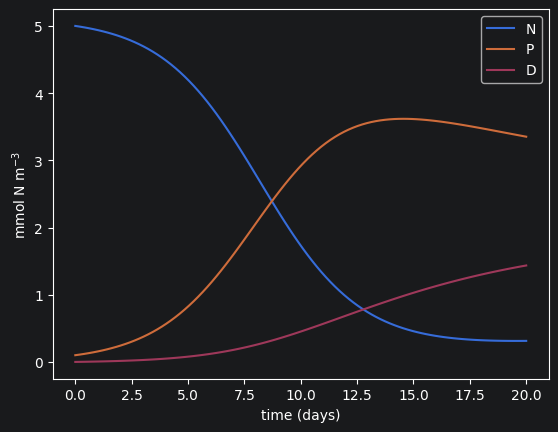

In [23]:
M = 0.05
R = 0.075
D0 = 0.0
state0 = np.array([N0,P0,D0])
# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,R,M,))

# plot the resulting time series
plt.plot(t,y[:,0],label='N')
plt.plot(t,y[:,1],label='P')
plt.plot(t,y[:,2],label='D')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()